<a href="https://colab.research.google.com/github/Jaffar-Kazmi/California-House-Price-Prediction/blob/main/California_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# California House Price Prediction

Dataset: https://www.kaggle.com/datasets/camnugent/california-housing-prices?resource=download

In [78]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler



In [6]:
df = pd.read_csv("housing.csv")

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [9]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


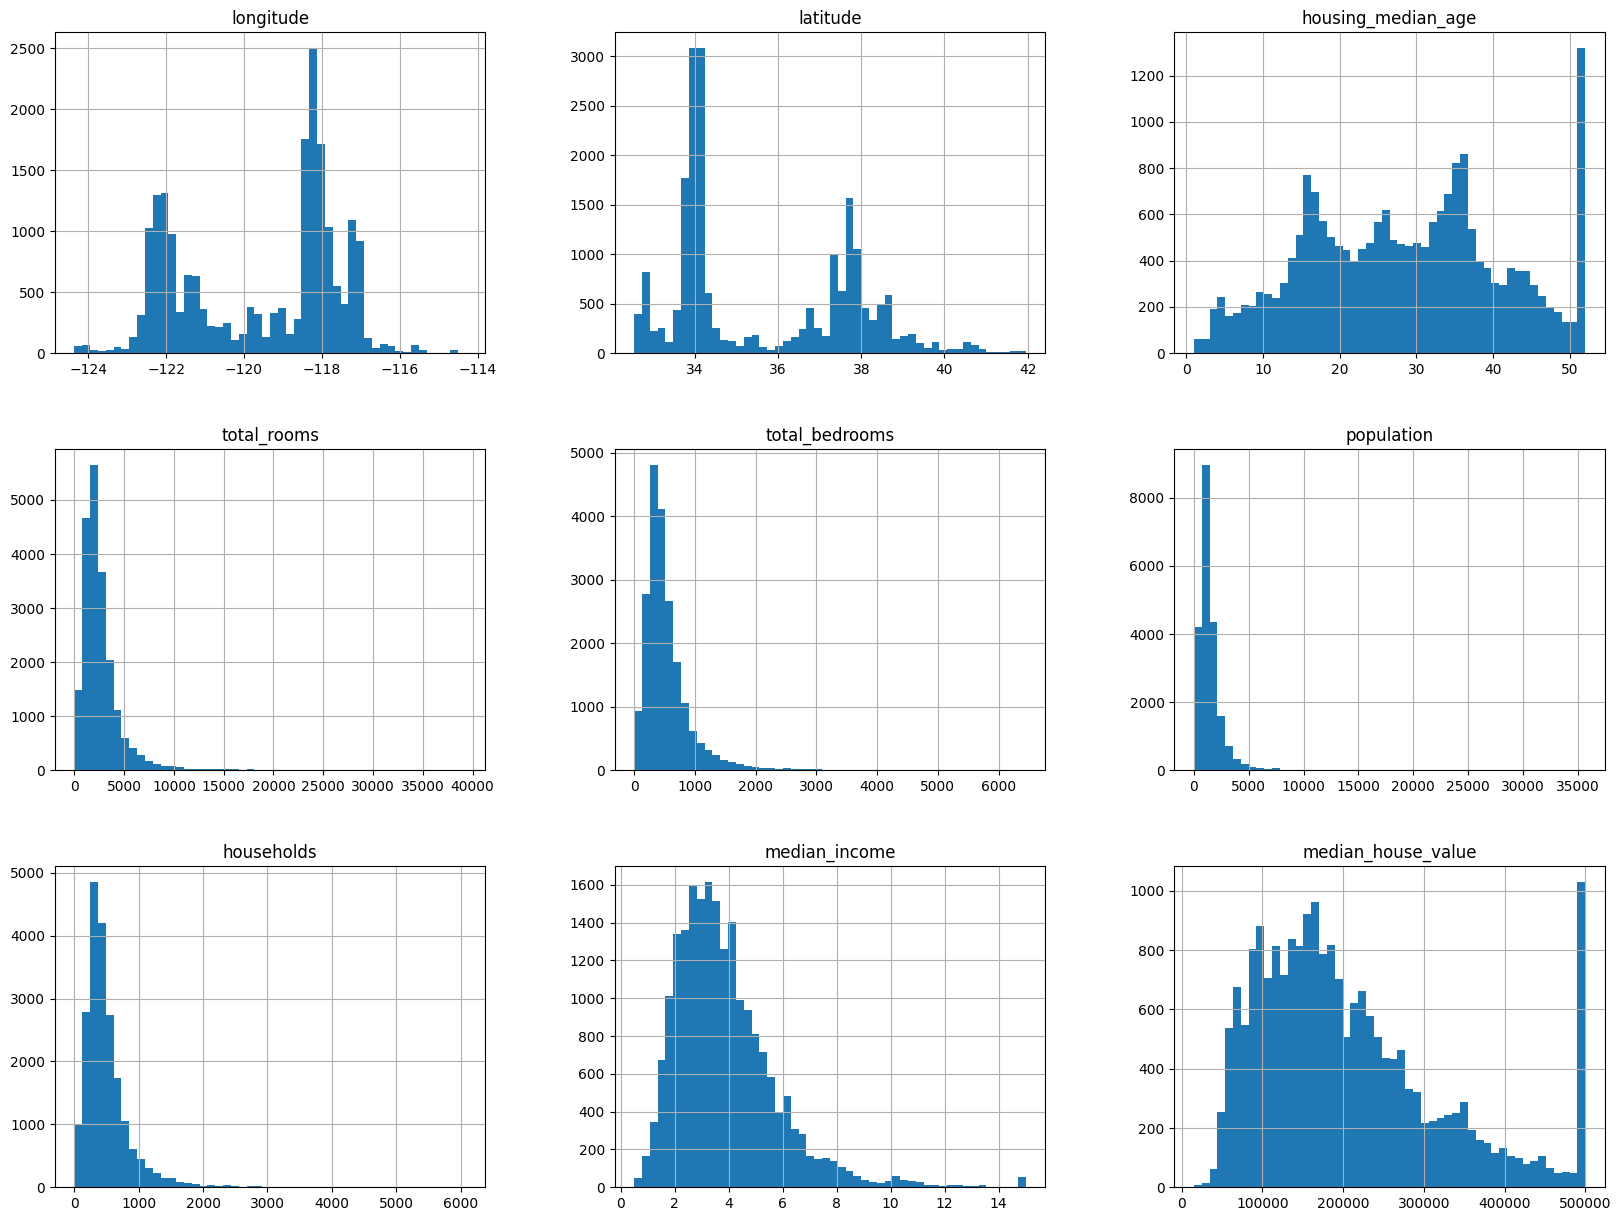

In [10]:
df.hist(bins=50, figsize=(20, 15))
plt.show()

In [11]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


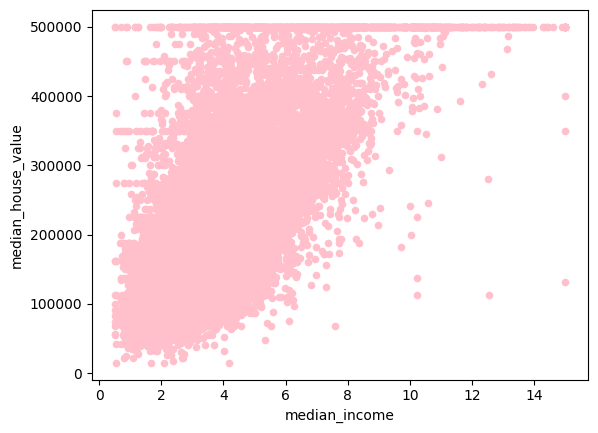

In [12]:
df.plot(kind='scatter', x='median_income', y='median_house_value', c='pink')

plt.show()

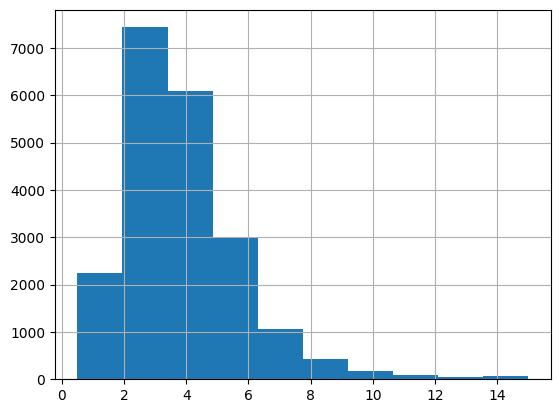

In [13]:
df['median_income'].hist()
plt.show()

In [14]:
df['income_cat'] = np.ceil(df['median_income'] / 1.5)
df['income_cat'] = df['income_cat'].where(df['income_cat'] < 5, 5.0)

In [15]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=29)

for train_index, test_index in split.split(df, df['income_cat']):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]


In [16]:
df['income_cat'].value_counts() / len(df)

,count
income_cat,
3.0,0.350581
2.0,0.318847
4.0,0.176308
5.0,0.114438
1.0,0.039826


In [17]:
strat_test_set['income_cat'].value_counts() / len(strat_test_set)

,count
income_cat,
3.0,0.350533
2.0,0.318798
4.0,0.176357
5.0,0.114341
1.0,0.039971


In [18]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [19]:
def income_cat_proportions(data):
  return data['income_cat'].value_counts() / len(data)

comparing_props = pd.DataFrame({
    'Original': income_cat_proportions(df),
    'Random_Test': income_cat_proportions(test_set),
    'Stratified_Test': income_cat_proportions(strat_test_set)
}).sort_index()

In [20]:
comparing_props['Random Error'] =  100 * comparing_props['Random_Test'] / comparing_props['Original'] - 100
comparing_props['Stratified Error'] = 100 * comparing_props['Stratified_Test'] / comparing_props['Original'] - 100

In [21]:
comparing_props

,Original,Random_Test,Stratified_Test,Random Error,Stratified Error
income_cat,,,,,
1.0,0.039826,0.040213,0.039971,0.973236,0.364964
2.0,0.318847,0.324370,0.318798,1.732260,-0.015195
3.0,0.350581,0.358527,0.350533,2.266446,-0.013820
4.0,0.176308,0.167393,0.176357,-5.056334,0.027480
5.0,0.114438,0.109496,0.114341,-4.318374,-0.084674


In [22]:
for item in (strat_train_set, strat_test_set):
  item.drop('income_cat', axis=1, inplace=True)

In [23]:
housing = strat_train_set.copy()

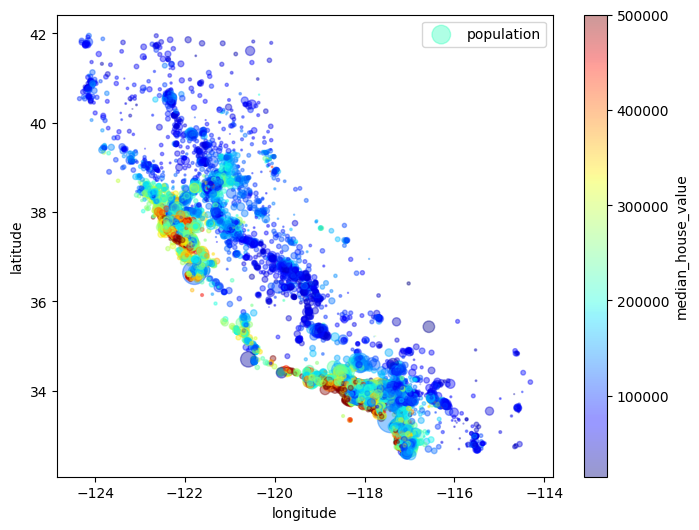

In [24]:
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.4,
             s=housing['population']/100, label='population', figsize=(8, 6),
             c='median_house_value', cmap=plt.get_cmap('jet'), colorbar=True)
plt.legend()

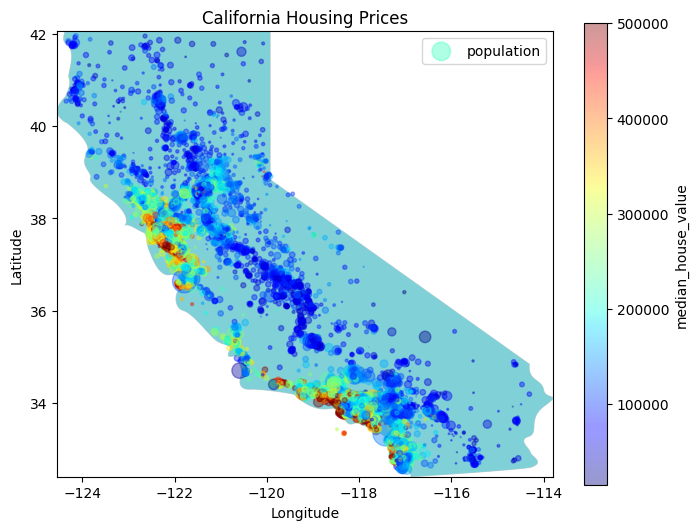

In [25]:
import matplotlib.image as mpimg

ax = housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.4,
             s=housing['population']/100, label='population', figsize=(8, 6),
             c='median_house_value', cmap=plt.get_cmap('jet'), sharex=False)

california_img = mpimg.imread('california.png')

plt.imshow(california_img, extent=[-124.55, -113.8, 32.4, 42.05], alpha=0.5, cmap=plt.get_cmap('jet'))

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices')

plt.show()

In [26]:
housing['population_per_household'] = housing['population'] / housing['households']
housing['rooms_per_household'] = housing['total_rooms'] / housing['households']
housing['bedrooms_per_room'] = housing['total_bedrooms'] / housing['total_rooms']

In [27]:
corr_matrix = housing.select_dtypes(include=[np.number]).corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.691334
rooms_per_household,0.151990
total_rooms,0.127498
housing_median_age,0.108481
households,0.060161
total_bedrooms,0.043991
population_per_household,-0.021681
population,-0.028239
longitude,-0.043977


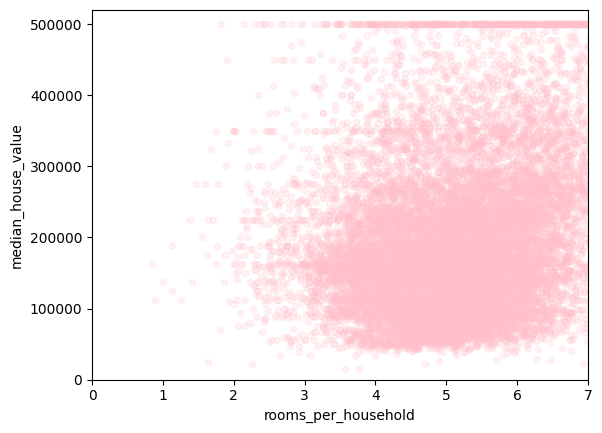

In [28]:
housing.plot(kind='scatter', x='rooms_per_household', y='median_house_value', alpha=0.2, c='pink')
plt.axis([0, 7, 0, 520000])
plt.show()

## *`Data Preprocessing`*

In [29]:
housing = strat_train_set.drop('median_house_value', axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

In [30]:
imputer = SimpleImputer(strategy='median')

housing_num = housing.select_dtypes(include=[np.number])

imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [31]:
housing_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 8007 to 230
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16349 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


In [32]:
X = imputer.transform(housing_num)

In [33]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

In [34]:
housing_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 8007 to 230
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


In [35]:
housing_cat = df['ocean_proximity'].copy()

In [36]:
housing_cat_encoded, housing_categories = housing_cat.factorize()

In [37]:
housing_cat_encoded[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [38]:
housing_categories

Index(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'], dtype='object')

In [39]:
encoder = OneHotEncoder()

housing_cat_1hot = encoder.fit_transform(housing_cat_encoded.reshape(1, -1))

In [40]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 20640 stored elements and shape (1, 20640)>

In [41]:
housing_cat_1hot.toarray()

array([[1., 1., 1., ..., 1., 1., 1.]])

In [52]:
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
  def __init__(self, add_bedrooms_per_room=True):
    self.add_bedrooms_per_room = add_bedrooms_per_room

  def fit(self, X, y=None):
        return self

  def transform(self, X, y=None):
    rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
    population_per_household = X[:, population_ix] / X[:, households_ix]

    if self.add_bedrooms_per_room:
      bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
      return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
    else:
      return np.c_[X, rooms_per_household, population_per_household]

In [54]:
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

In [55]:
housing_extra_attribs = pd.DataFrame(housing_extra_attribs, columns=list(housing.columns)+["rooms_per_household", "population_per_household"])
housing_extra_attribs.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,population_per_household
0,-118.11,33.85,36.0,887.0,163.0,482.0,157.0,4.125,<1H OCEAN,5.649682,3.070064
1,-122.04,37.33,26.0,2690.0,401.0,1264.0,429.0,7.7643,<1H OCEAN,6.270396,2.946387
2,-117.74,34.1,29.0,2742.0,488.0,2477.0,532.0,3.5072,INLAND,5.154135,4.656015
3,-118.39,34.23,43.0,1193.0,299.0,1184.0,320.0,2.1518,<1H OCEAN,3.728125,3.7
4,-117.11,32.76,21.0,2226.0,600.0,1085.0,533.0,2.2604,NEAR OCEAN,4.17636,2.035647


In [56]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("std_scaler", StandardScaler())
])

housing_num_tr = num_pipeline.fit_transform(housing_num)
housing_num_tr

array([[ 0.73060355, -0.83678622,  0.5859237 , ...,  0.08523298,
        -0.00292009, -0.45066285],
       [-1.22941925,  0.78729756, -0.21189695, ...,  0.33148459,
        -0.01357928, -0.97149216],
       [ 0.91513496, -0.72011354,  0.02744924, ..., -0.11136143,
         0.13376642, -0.53762897],
       ...,
       [ 0.201946  , -0.63144229, -0.85015347, ...,  0.13786673,
        -0.02720971, -0.4451879 ],
       [ 0.63085685, -0.73878116, -0.37146108, ..., -0.91194187,
        -0.01098173,  1.88075105],
       [-1.30921661,  1.0019753 ,  0.90505196, ..., -0.3666513 ,
        -0.02289502,  0.4161723 ]])

In [79]:
# Define features
num_attribs = list(housing_num.columns)
cat_attribs = ['ocean_proximity']

# Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("std_scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("cat_encoder", OneHotEncoder())
])

# Full pipeline using ColumnTransformer
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

housing_prepared = full_pipeline.fit_transform(housing)

In [86]:
strat_test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
10220,-117.88,33.88,15.0,957.0,360.0,615.0,370.0,3.0263,162500.0,<1H OCEAN
70,-122.29,37.81,26.0,768.0,152.0,392.0,127.0,1.7719,82500.0,NEAR BAY
12578,-121.44,38.53,37.0,1951.0,432.0,1089.0,411.0,2.3272,80600.0,INLAND
17917,-121.99,37.36,33.0,2545.0,467.0,1287.0,458.0,5.5000,282200.0,<1H OCEAN
18335,-122.16,37.44,34.0,2199.0,529.0,1193.0,532.0,4.2972,405900.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
2756,-115.50,32.68,18.0,3631.0,913.0,3565.0,924.0,1.5931,88400.0,INLAND
244,-122.22,37.78,44.0,2968.0,710.0,2269.0,610.0,2.3906,111700.0,NEAR BAY
13364,-117.66,34.00,5.0,1387.0,236.0,855.0,270.0,5.4110,201100.0,INLAND
16896,-122.36,37.58,37.0,3325.0,734.0,1468.0,692.0,4.0987,434000.0,NEAR OCEAN


In [85]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
8007,-118.11,33.85,36.0,887.0,163.0,482.0,157.0,4.1250,<1H OCEAN
18096,-122.04,37.33,26.0,2690.0,401.0,1264.0,429.0,7.7643,<1H OCEAN
5981,-117.74,34.10,29.0,2742.0,488.0,2477.0,532.0,3.5072,INLAND
3669,-118.39,34.23,43.0,1193.0,299.0,1184.0,320.0,2.1518,<1H OCEAN
14092,-117.11,32.76,21.0,2226.0,600.0,1085.0,533.0,2.2604,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...
16800,-122.42,37.67,42.0,2274.0,429.0,1255.0,397.0,5.1205,NEAR OCEAN
2725,-115.55,32.79,22.0,565.0,162.0,692.0,141.0,1.2083,INLAND
20173,-119.17,34.29,18.0,3932.0,724.0,1896.0,680.0,5.2953,NEAR OCEAN
4644,-118.31,34.06,24.0,1336.0,453.0,1268.0,426.0,2.8202,<1H OCEAN


## Selecting & Models

### 1. Linear Regression

In [82]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [87]:
data = housing.iloc[:5]
labels = housing_labels.iloc[:5]
data_prepared = full_pipeline.transform(data)

print("Predictions: ", lin_reg.predict(data_prepared))
print("Labels: ", list(labels))

Predictions:  [232035.89112672 380482.2530773  112115.91222308 157188.4422259
 182226.68776252]
Labels:  [219500.0, 474700.0, 121900.0, 161600.0, 126300.0]


In [88]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(67932.7700373929)